# Initialization of libraries to be used as well as loading of the data. <br>
> additionally remove rows that are not relevant.

In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sb
plt.style.use('seaborn-v0_8-whitegrid')
sb.set_palette("husl")

In [196]:
df = pd.read_csv("data/beatmaps.csv")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.8f}'.format)
print(df.columns.to_list())
df = df.drop(columns=['file_md5', 'tags', 'download_unavailable', 'audio_unavailable'])

['beatmapset_id', 'beatmap_id', 'approved', 'total_length', 'hit_length', 'version', 'file_md5', 'diff_size', 'diff_overall', 'diff_approach', 'diff_drain', 'mode', 'count_normal', 'count_slider', 'count_spinner', 'submit_date', 'approved_date', 'last_update', 'artist', 'title', 'creator', 'creator_id', 'bpm', 'source', 'tags', 'genre_id', 'language_id', 'favourite_count', 'rating', 'download_unavailable', 'audio_unavailable', 'playcount', 'passcount', 'max_combo', 'diff_aim', 'diff_speed', 'difficultyrating']


# Adjust the data by removing rows that are not relevant to this project. <br>
> Remove all rows where mode is not 0 (the standard osu game mode). <br>
> Remove all rows that are either pending (0), WIP (-1), or graveyard (-2) <br>
> Remove all rows where the total song time is less than 40 seconds or greater than 2 standard deviations from the mean. <br>
> Remove all rows where the Drain Ratio (Hit length / Total Length) is less than 0.6, This means that the map is less than 60% game time and a large part is empty audio (intros, outros, massive breaks) and is a good indicator of > a low-quality beatmap. <br>
>Remove maps where there are impossible statisitcs / data collection inaccurary (bpm >= 500, difficultyrating >= 11) <br>
Any map that falls into one of these categories will be considered as these maps are generally incomplete or of low quality (meme maps, endurance maps, practice maps, etc).

In [197]:
# Drop the rows using their indices, modifying the DataFrame in-place
df.drop(df[df['mode'] != 0].index, inplace= True)
df.drop(df[df['approved'].isin([0, -1, -2])].index, inplace=True)
#calculate bounds
total_length_mean_val = df['total_length'].mean()
total_length_std_val = df['total_length'].std()
hit_length_mean_val = df['hit_length'].mean()
hit_length_std_val = df['hit_length'].std()
min_total_length = 40
max_total_length = total_length_mean_val + 2 * total_length_std_val
max_hit_length = hit_length_mean_val + 2 * hit_length_std_val
# Overwrite df with only the rows that meet the length criteria
df = df[
    (df['total_length'] >= min_total_length) & 
    (df['total_length'] <= max_total_length) &
    (df['hit_length'] >= min_total_length) &
    (df['hit_length'] <= max_hit_length)
]

# Calculate drain ratio, keep the high-quality maps, and drop the temporary column
df['drain_ratio'] = df['hit_length'] / df['total_length']
df = df[df['drain_ratio'] >= 0.60]
df = df.drop(columns=['drain_ratio'])

#Remove impossible beatmaps
df.drop(df[(df['bpm'] >= 500) | (df['bpm'] == 0)].index, inplace=True)
df.drop(df[df['difficultyrating'] >= 11].index, inplace= True)

# Summary statistics for the key numerical variables involved in our analysis.

In [198]:
df[['total_length', 'bpm', 'difficultyrating', 'count_normal', 'count_slider', 'count_spinner', 'playcount', 'favourite_count']].describe().round(2)

,total_length,bpm,difficultyrating,count_normal,count_slider,count_spinner,playcount,favourite_count
count,61686.00000000,61686.00000000,61686.00000000,61686.00000000,61686.00000000,61686.00000000,61686.00000000,61686.00000000
mean,139.65000000,155.29000000,3.26000000,181.01000000,139.91000000,2.23000000,152645.31000000,278.73000000
std,59.34000000,37.13000000,1.40000000,156.71000000,95.58000000,2.62000000,413711.37000000,538.04000000
min,40.00000000,15.00000000,0.43000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
25%,89.00000000,131.00000000,2.05000000,70.00000000,73.00000000,1.00000000,24129.50000000,61.00000000
50%,118.00000000,160.00000000,3.12000000,135.00000000,117.00000000,2.00000000,56897.00000000,131.00000000
75%,189.00000000,180.00000000,4.25000000,242.00000000,177.00000000,3.00000000,142382.50000000,285.00000000
max,299.00000000,468.75000000,10.48000000,1955.00000000,1106.00000000,212.00000000,25960995.00000000,15419.00000000


# Exploratory Data Analysis (EDA)

## Distribution of Playcount <br>
Typically playcounts follow an exponential distribution, most maps have a low playcount, while a few "mega-hits" garner millions of plays. By applying a logarithmic transformation, we can better visualize the spread of the data.

Text(0, 0.5, 'Frequency')

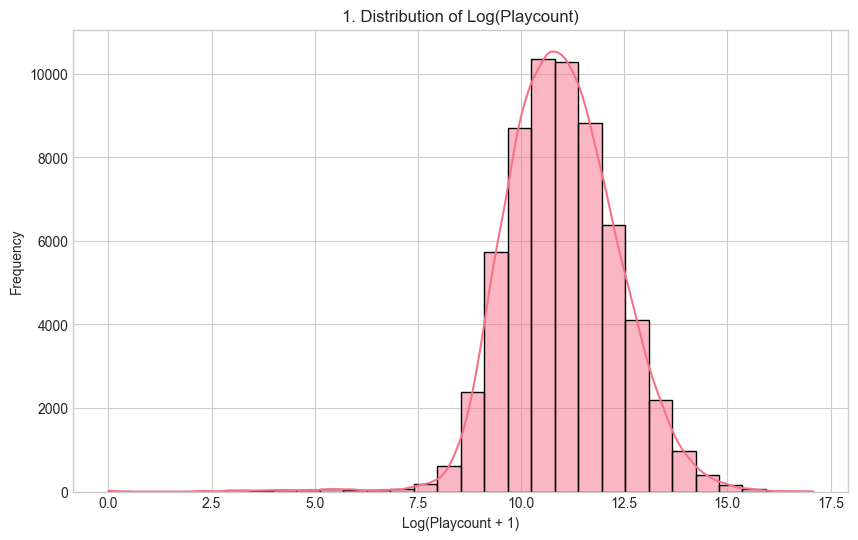

In [199]:
# 1. Distribution of Log(Playcount)
plt.figure(figsize=(10, 6))
sb.histplot(np.log1p(df['playcount']), bins=30, kde=True)
plt.title('1. Distribution of Log(Playcount)')
plt.xlabel('Log(Playcount + 1)')
plt.ylabel('Frequency')

## BPM Distribution: Popular vs Normal Maps
We segmented the top 10% most played maps and compared their BPM distribution to the rest of the dataset.

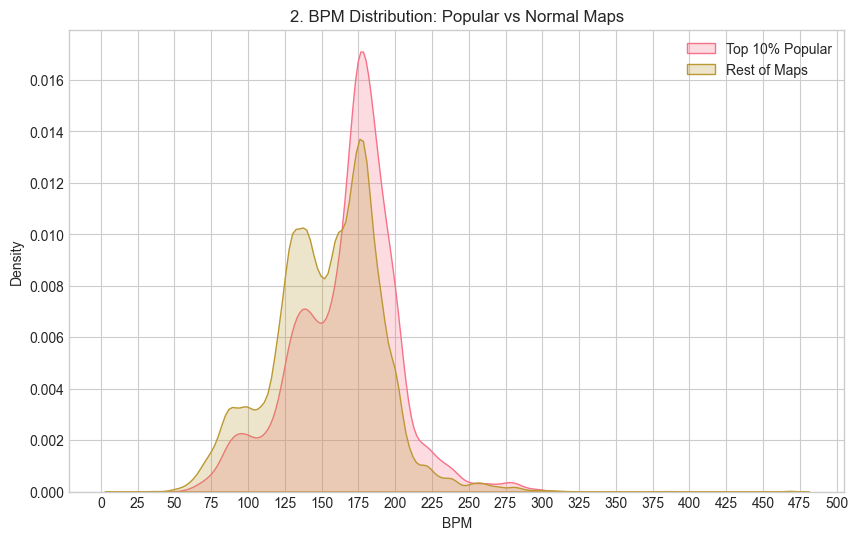

In [ ]:
# Calculate Top 10%
top_10 = df[df['playcount'] > df['playcount'].quantile(0.9)]
rest = df[df['playcount'] <= df['playcount'].quantile(0.9)]

plt.figure(figsize=(10, 6))
sb.kdeplot(top_10['bpm'], label='Top 10% Popular', fill=True)
sb.kdeplot(rest['bpm'], label='Rest of Maps', fill=True)
plt.title('2. BPM Distribution: Popular vs Normal Maps')
plt.xlabel('BPM')
plt.ylabel('Density')
plt.gca().xaxis.set_major_locator(MultipleLocator(25))  #set x axsis ticker to a multiple of 25
plt.legend()

## Total Length Distrubition: Popular vs. Normal Maps
Similar to BPM, this looks at song length. Most popular beatmaps often fall into the "TV Size" category (roughly 90 seconds, around the same time as a typical TV anime opening) because they are quick to retry and farm for performance points (PP).

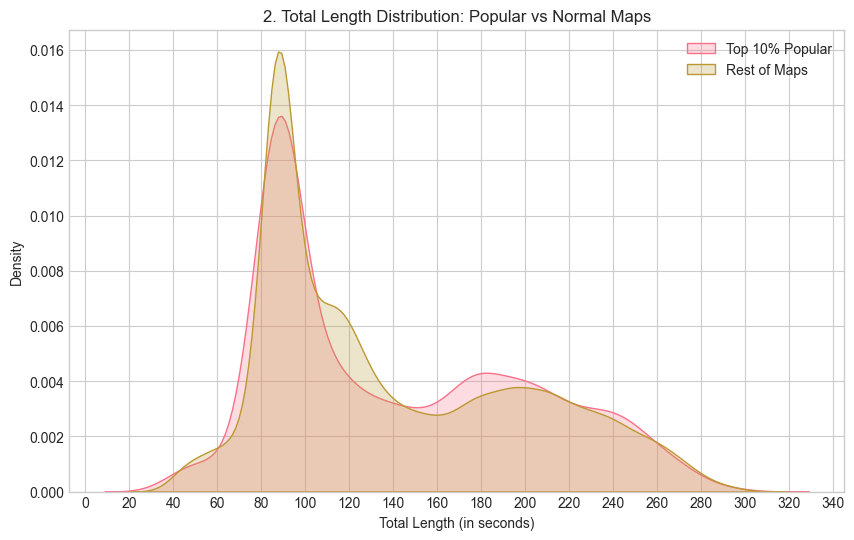

In [205]:
plt.figure(figsize=(10, 6))
sb.kdeplot(top_10['total_length'], label='Top 10% Popular', fill=True)
sb.kdeplot(rest['total_length'], label='Rest of Maps', fill=True)
plt.title('2. Total Length Distribution: Popular vs Normal Maps')
plt.xlabel('Total Length (in seconds)')
plt.ylabel('Density')
plt.gca().xaxis.set_major_locator(MultipleLocator(20))
plt.legend()